# EDA with MEDCIC data

In [1]:
import os
import pydicom
import numpy as np
import zarr
import dask.array as da
import matplotlib.pyplot as plt
import glob
import pydicom
from ipywidgets import interact, IntSlider

import dicom_to_zarr
import helpers

Convertion of dicom data.

In [39]:
# Define paths (please adjust if needed)
dicom_folder = 'MRI-Datasets/159277_B1/15/DICOM' 
zarr_file = 'MRI-Datasets/Converted_to_zarr/159277_B1.zarr'

# Make sure the folder exists before calling the function
if not os.path.exists(dicom_folder):
    os.makedirs(dicom_folder)
    print(f"Folder '{dicom_folder}' was created. Please fill it with your DICOM files.")
elif not os.listdir(dicom_folder):
    print(f"The folder '{dicom_folder}' is empty. Please add DICOM files to run the script.")
else:
    # Call the conversion function
    dicom_to_zarr.convert_dicom_to_zarr(dicom_folder, zarr_file)

Lese DICOM-Dateien aus: MRI-Datasets/159277_B1/15/DICOM
Stapele DICOM-Schichten zu einem 3D-Raum...
Extrahierte Metadaten: {'PixelSpacing': [1.9531, 1.9531], 'SliceThickness': 5.0, 'Rows': 256, 'Columns': 256, 'PatientID': 'MEDCIC_07_B1'}
Speichere Array der Größe (12500, 256, 256) in MRI-Datasets/Converted_to_zarr/159277_B1.zarr...
Konvertierung abgeschlossen!


## Exploratory Data Analysis (EDA) of the Zarr File

In [40]:
try:
    z_array = zarr.open(zarr_file, mode='r')

    # Print metadata and array properties
    metadata = z_array.attrs['metadata']
    print(f"Zarr array successfully loaded.")
    print(f"Shape: {z_array.shape}")
    print(f"Dtype: {z_array.dtype}")
    print(f"Stored Metadata: {metadata}")
    
    DATA_LOADED = True
except FileNotFoundError:
    print(f"Error: '{zarr_file}' not found. Please ensure Part 1 ran successfully.")
    DATA_LOADED = False

Zarr array successfully loaded.
Shape: (12500, 256, 256)
Dtype: int16
Stored Metadata: {'PixelSpacing': [1.9531, 1.9531], 'SliceThickness': 5.0, 'Rows': 256, 'Columns': 256, 'PatientID': 'MEDCIC_07_B1'}


In [41]:
# Load the Zarr store into a Dask array
# This operation is lazy and loads no data
try:
    dask_array = da.from_zarr(zarr_file)
    DATA_LOADED = True
except FileNotFoundError:
    print(f"Error: Zarr file '{zarr_file}' not found. Make sure Part 1 was successful.")
    DATA_LOADED = False

In [42]:
dask_array

dask.array<from-zarr, shape=(12500, 256, 256), dtype=int16, chunksize=(64, 128, 128), chunktype=numpy.ndarray>

In [ ]:
dask_array = np.transpose(dask_array, [0,1,2])
dask_array = dask_array.reshape([250,50,256,256])
dask_array = np.transpose(dask_array, [3,2,1,0])


In [68]:
dask_array

dask.array<transpose, shape=(256, 256, 50, 250), dtype=int16, chunksize=(128, 128, 50, 1), chunktype=numpy.ndarray>

In [63]:
new_shape = zarr.create_array(z_array, shape=[250,50,256,256])
#new_shape = np.reshape(z_array, (250, 50, 256, 256))
new_shape = np.transpose(new_shape, [3,2,1,0])

ValueError: The data parameter was set to None, but dtype was not specified.Either provide an array-like value for data, or specify dtype.

In [52]:
new_shape

dask.array<transpose, shape=(256, 256, 50, 250), dtype=int16, chunksize=(128, 128, 50, 1), chunktype=numpy.ndarray>

Visualization: Displaying Slices

In [73]:
slide_array = dask_array[:,:,:,125]
slide_array = np.transpose(slide_array, [2,1,0])

In [74]:
helpers.explore_3D_array(slide_array)

interactive(children=(IntSlider(value=24, description='SLICE', max=49), Output()), _dom_classes=('widget-inter…

In [ ]:
metadata = {'PixelSpacing': [0.8, 0.8], 'SliceThickness': 2.5}
helpers.explore_orthogonal_views(z_array, metadata)

interactive(children=(IntSlider(value=3, description='Axial (Z):', max=7), IntSlider(value=127, description='C…

Calculating histogram for the first scan...


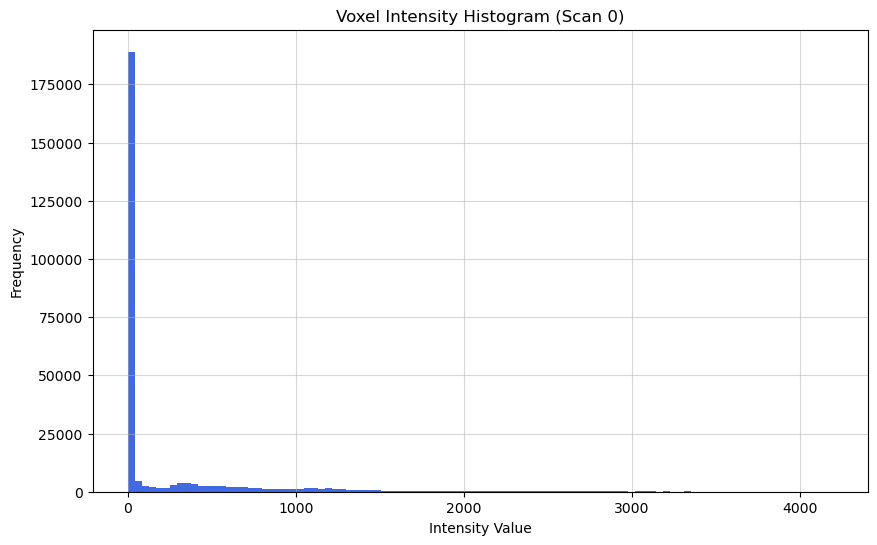

In [ ]:
# Calculate histogram using Dask. This is still lazy.
# We select the first scan for this example
print("Calculating histogram for the first scan...")
first_scan_array = dask_array[0, :, :]

# Define histogram bins
bins = np.linspace(first_scan_array.min().compute(), first_scan_array.max().compute(), 101)

# Compute the histogram. This is where the actual computation happens.
counts, edges = da.histogram(first_scan_array, bins=bins)
hist_counts, hist_edges = counts.compute(), edges # .compute() to get results
# Plot the results
plt.figure(figsize=(10, 6))
plt.bar(hist_edges[:-1], hist_counts, width=np.diff(hist_edges), align='edge', color='royalblue')
plt.title('Voxel Intensity Histogram (Scan 0)')
plt.xlabel('Intensity Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.5)
plt.show()

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import zarr
import tqdm  # Für eine schöne Fortschrittsanzeige

# =================================================================================
# 1. MODELL-DEFINITIONEN (müssen mit dem Training identisch sein)
# =================================================================================
# Kopiere die Klassen 'SpatialTransformer3D', 'UNet3D' und 'RegistrationModel'
# aus deinen vorherigen Skripten hierher.
class SpatialTransformer3D(nn.Module):
    def __init__(self, size):
        super().__init__()
        vectors = [torch.arange(0, s) for s in size]
        grids = torch.meshgrid(vectors, indexing='ij')
        grid = torch.stack(grids)
        grid = grid.unsqueeze(0)
        self.register_buffer('grid', grid.float(), persistent=False)
    def forward(self, src, flow):
        new_locs = self.grid + flow
        shape = flow.shape[2:]
        for i in range(len(shape)):
            new_locs[:, i, ...] = 2 * (new_locs[:, i, ...] / (shape[i] - 1) - 0.5)
        new_locs = new_locs.permute(0, 2, 3, 4, 1)
        new_locs = new_locs[..., [2, 1, 0]]
        return F.grid_sample(src, new_locs, align_corners=True, padding_mode="border")

class UNet3D(nn.Module):
    def __init__(self, in_channels=2, out_channels=3):
        super().__init__()
        self.enc1 = self._conv_block(in_channels, 16)
        self.enc2 = self._conv_block(16, 32)
        self.pool = nn.MaxPool3d(2)
        self.bottleneck = self._conv_block(32, 64)
        self.upconv2 = nn.ConvTranspose3d(64, 32, kernel_size=2, stride=2)
        self.dec2 = self._conv_block(64, 32)
        self.upconv1 = nn.ConvTranspose3d(32, 16, kernel_size=2, stride=2)
        self.dec1 = self._conv_block(32, 16)
        self.final_conv = nn.Conv3d(16, out_channels, kernel_size=1)
        self.final_conv.weight.data.zero_()
        self.final_conv.bias.data.zero_()
    def _conv_block(self, in_c, out_c):
        return nn.Sequential(nn.Conv3d(in_c, out_c, 3, 1, 1), nn.ReLU(True), nn.Conv3d(out_c, out_c, 3, 1, 1), nn.ReLU(True))
    def forward(self, x_fixed, x_moving):
        x = torch.cat([x_fixed, x_moving], dim=1)
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        b = self.bottleneck(self.pool(e2))
        d2 = self.upconv2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        d1 = self.upconv1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        return self.final_conv(d1)

class RegistrationModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.registration_net = UNet3D()
        self.spatial_transformer = SpatialTransformer3D(size=input_size)
    def forward(self, moving, fixed):
        displacement_field = self.registration_net(fixed, moving)
        warped_moving = self.spatial_transformer(moving, displacement_field)
        return warped_moving, displacement_field

# =================================================================================
# 2. BATCH-VERARBEITUNGS-SKRIPT
# =================================================================================
if __name__ == '__main__':
    # --- Konfiguration ---
    MODEL_PATH = "../DCE_codeset/registration_model_Bat1_50Ep_1e-3_NewLoss_SmoothWeight1e-3.pth"
    #INPUT_ZARR_PATH = "/media/shooty/Dev/repos/MRI-MoCoCo/MRI-Datasets/mdreg_DCE_fitting_results/coreg_zarr_2.zarr"
    OUTPUT_ZARR_PATH = "MEDCIC_07_codeset/MRI-Datasets/Outputs/warped_test/warped_results_model_test1.zarr"
    OUTPUT_DVF_PATH = "MEDCIC_07_codeset/MRI-Datasets/Outputs/warped_test/dvf_results_model_test1.zarr"

    # --- Setup ---
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Verwende Gerät: {device}")

    if os.path.exists(OUTPUT_ZARR_PATH) or os.path.exists(OUTPUT_DVF_PATH):
        raise FileExistsError("Eine der Ausgabedateien existiert bereits. Bitte löschen oder umbenennen.")

    dask_array = dask_array

    # --- Modell laden ---
    print(f"Lade trainiertes Modell von: {MODEL_PATH}")
    # KORREKTUR: .compute() hier entfernt. Shape wird direkt vom Dask-Objekt genommen.
    original_shape = dask_array.shape 
    padded_shape = list(original_shape[:3]) # Nimm H, W, D
    
    for i in range(3):
        if padded_shape[i] % 4 != 0:
            padded_shape[i] = (padded_shape[i] // 4 + 1) * 4
    input_size = (padded_shape[2], padded_shape[0], padded_shape[1])

    model = RegistrationModel(input_size=input_size).to(device)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()
    print("Modell erfolgreich geladen.")

    # --- Daten-Setup ---
    # KORREKTUR: Die .compute() Aufrufe hier werden entfernt. 
    # Wir arbeiten direkt mit dem 'dask_array'-Objekt.
    
    # Erstelle die leere Zarr-Datei für die Ausgabe
    print(f"Erstelle Ausgabedatei: {OUTPUT_ZARR_PATH}")
    output_zarr = zarr.open(OUTPUT_ZARR_PATH, mode='w', 
                            shape=dask_array.shape, 
                            # KORREKTUR: .chunksize für Dask-Arrays, .chunks für Zarr-Arrays
                            chunks=dask_array.chunksize, 
                            dtype=dask_array.dtype)
    
    dvf_shape = list(dask_array.shape) + [3]
    dvf_chunks = list(dask_array.chunksize) + [3]
    dvf_output_zarr = zarr.open(OUTPUT_DVF_PATH, mode='w',
                                shape=tuple(dvf_shape),
                                chunks=tuple(dvf_chunks),
                                dtype='float32')

    # --- Lade das fixe Referenzbild vor ---
    print("Lade und verarbeite fixes Referenzbild...")
    # KORREKTUR: .compute() wird hier nur für das EINE Referenzbild aufgerufen
    fixed_np = dask_array[..., 0].compute() 
    
    def preprocess_volume(volume_np, padded_shape):
        tensor = torch.from_numpy(volume_np.astype(np.float32)).permute(2, 0, 1)
        tensor = tensor.unsqueeze(0)
        pad_d = padded_shape[2] - tensor.shape[1]
        pad_h = padded_shape[0] - tensor.shape[2]
        pad_w = padded_shape[1] - tensor.shape[3]
        padding = (pad_w // 2, pad_w - pad_w // 2, pad_h // 2, pad_h - pad_h // 2, pad_d // 2, pad_d - pad_d // 2)
        return F.pad(tensor, padding, "constant", 0)

    fixed_tensor = preprocess_volume(fixed_np, padded_shape).to(device)
    fixed_tensor_batch = fixed_tensor.unsqueeze(0)

    # --- Hauptverarbeitungsschleife ---
    num_images = dask_array.shape[3]
    print(f"Starte Verarbeitung von {num_images} Volumen...")

    with torch.no_grad():
        for i in tqdm.trange(num_images, desc="Verarbeite Volumen"):
            # 1. Lese ein "moving" Volumen und lade es mit .compute() in den Speicher
            # KORREKTUR: Lade nur das aktuell benötigte Volumen!
            moving_np = dask_array[..., i].compute()
            
            # 2. Wende die gleiche Vorverarbeitung an
            moving_tensor = preprocess_volume(moving_np, padded_shape).to(device)
            moving_tensor_batch = moving_tensor.unsqueeze(0)

            # 3. Führe die Inferenz durch
            warped_batch, displacement_batch = model(moving_tensor_batch, fixed_tensor_batch)

            # 4. Nachbearbeitung
            warped_tensor = warped_batch.squeeze(0)
            disp_field = displacement_batch.squeeze(0)
            
            pad_d_start = (padded_shape[2] - original_shape[2]) // 2
            pad_h_start = (padded_shape[0] - original_shape[0]) // 2
            pad_w_start = (padded_shape[1] - original_shape[1]) // 2
            
            cropped_warped = warped_tensor[:, pad_d_start:pad_d_start + original_shape[2], pad_h_start:pad_h_start + original_shape[0], pad_w_start:pad_w_start + original_shape[1]]
            cropped_disp = disp_field[:, pad_d_start:pad_d_start + original_shape[2], pad_h_start:pad_h_start + original_shape[0], pad_w_start:pad_w_start + original_shape[1]]
            
            warped_np = cropped_warped.squeeze(0).cpu().numpy().transpose(1, 2, 0)
            dvf_np = cropped_disp.permute(2, 3, 1, 0).cpu().numpy()

            # 5. Speichere das Ergebnis
            output_zarr[..., i] = warped_np
            dvf_output_zarr[..., i, :] = dvf_np
            
    print(f"\n✔️ Verarbeitung abgeschlossen.")
    print(f"Ergebnisse gespeichert in: {OUTPUT_ZARR_PATH}")
    print(f"DVF gespeichert in: {OUTPUT_DVF_PATH}")

Verwende Gerät: cuda
Lade trainiertes Modell von: ../DCE_codeset/registration_model_Bat1_50Ep_1e-3_NewLoss_SmoothWeight1e-3.pth
Modell erfolgreich geladen.
Erstelle Ausgabedatei: MEDCIC_07_codeset/MRI-Datasets/Outputs/warped_test/warped_results_model_test1.zarr
Lade und verarbeite fixes Referenzbild...
Starte Verarbeitung von 250 Volumen...


Verarbeite Volumen: 100%|██████████| 250/250 [02:54<00:00,  1.43it/s]


✔️ Verarbeitung abgeschlossen.
Ergebnisse gespeichert in: MEDCIC_07_codeset/MRI-Datasets/Outputs/warped_test/warped_results_model_test1.zarr
DVF gespeichert in: MEDCIC_07_codeset/MRI-Datasets/Outputs/warped_test/dvf_results_model_test1.zarr


In [82]:
out = da.from_array(output_zarr)
out

dask.array<array, shape=(256, 256, 50, 250), dtype=int16, chunksize=(256, 256, 50, 20), chunktype=numpy.ndarray>

In [87]:
dask_array

dask.array<transpose, shape=(256, 256, 50, 250), dtype=int16, chunksize=(128, 128, 50, 1), chunktype=numpy.ndarray>

In [92]:
slide_array = out[:,:,14,:]
slide_array = np.transpose(slide_array, [2,1,0])

In [93]:
slide_array_2 = dask_array[:,:,14,:]
slide_array_2 = np.transpose(slide_array_2, [2,1,0])

In [94]:
helpers.explore_3D_array_comparison_and_diff(slide_array_2,slide_array)

interactive(children=(IntSlider(value=125, description='Slice:', max=249), Output()), _dom_classes=('widget-in…

In [95]:
slide_array = out[:,:,15,:]
slide_array = np.transpose(slide_array, [2,1,0])
slide_array_2 = dask_array[:,:,15,:]
slide_array_2 = np.transpose(slide_array_2, [2,1,0])

In [ ]:
helpers.explore_3D_array_comparison_and_diff(slide_array_2,slide_array)

interactive(children=(IntSlider(value=125, description='Slice:', max=249), Output()), _dom_classes=('widget-in…

In [97]:
slide_array = out[:,:,16,:]
slide_array = np.transpose(slide_array, [2,1,0])
slide_array_2 = dask_array[:,:,16,:]
slide_array_2 = np.transpose(slide_array_2, [2,1,0])

In [98]:
helpers.explore_3D_array_comparison_and_diff(slide_array_2,slide_array)

interactive(children=(IntSlider(value=125, description='Slice:', max=249), Output()), _dom_classes=('widget-in…

In [99]:
slide_array = out[:,:,17,:]
slide_array = np.transpose(slide_array, [2,1,0])
slide_array_2 = dask_array[:,:,17,:]
slide_array_2 = np.transpose(slide_array_2, [2,1,0])

In [ ]:
helpers.explore_3D_array_comparison_and_diff(slide_array_2,slide_array)

interactive(children=(IntSlider(value=125, description='Slice:', max=249), Output()), _dom_classes=('widget-in…

In [101]:
slide_array = out[:,:,18,:]
slide_array = np.transpose(slide_array, [2,1,0])
slide_array_2 = dask_array[:,:,18,:]
slide_array_2 = np.transpose(slide_array_2, [2,1,0])

In [ ]:
helpers.explore_3D_array_comparison_and_diff(slide_array_2,slide_array)

interactive(children=(IntSlider(value=125, description='Slice:', max=249), Output()), _dom_classes=('widget-in…

In [104]:
z_array.attrs

In [122]:
slide=17
slide_array = out[:,:,slide,:]
slide_array = np.transpose(slide_array, [2,1,0])
slide_array_2 = dask_array[:,:,slide,:]
slide_array_2 = np.transpose(slide_array_2, [2,1,0])

In [ ]:
helpers.explore_3D_array_comparison_and_diff(slide_array_2,slide_array)

interactive(children=(IntSlider(value=125, description='Slice:', max=249), Output()), _dom_classes=('widget-in…